In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import cifar10

In [7]:
# Load CIFAR-10 Dataset

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)

print("\nTesting Images Shape :", X_test.shape)
print("Testing Labels Shape :", y_test.shape)

Training Images Shape : (50000, 32, 32, 3)
Training Labels Shape : (50000, 1)

Testing Images Shape : (10000, 32, 32, 3)
Testing Labels Shape : (10000, 1)


In [8]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]


In [9]:
import os

# Create folder
save_dir = "plots_eps"
os.makedirs(save_dir, exist_ok=True)

In [10]:
def save_plot(name):
    plt.savefig(
        f"{save_dir}/{name}.eps",
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )
    print(f"Saved: {name}.eps")

Saved: sample_images.eps


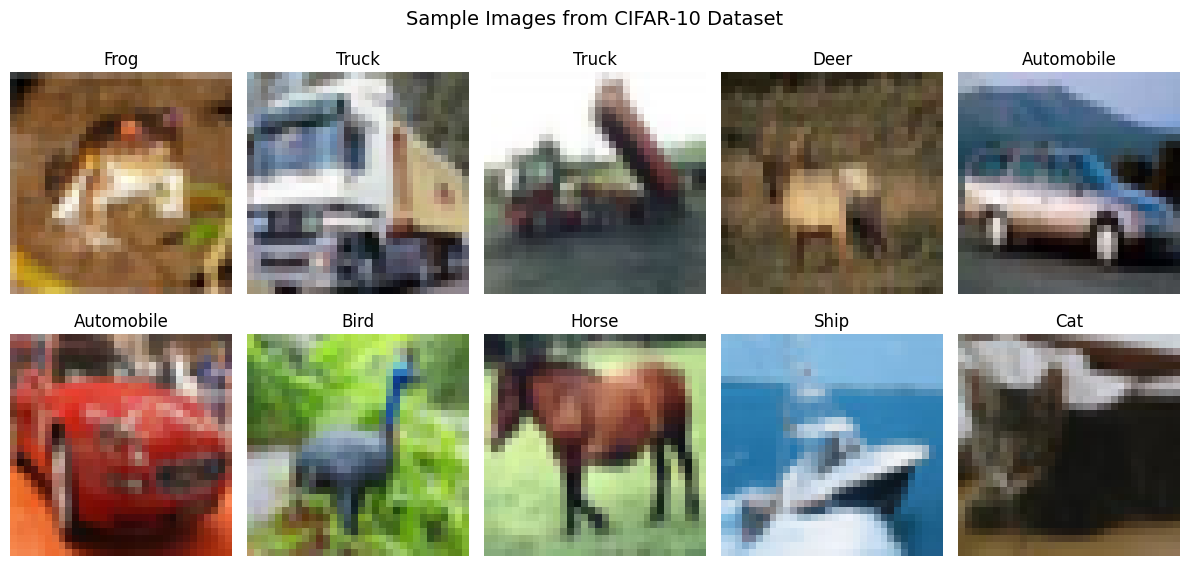

In [11]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.suptitle("Sample Images from CIFAR-10 Dataset", fontsize=14)
plt.tight_layout()
save_plot("sample_images")
plt.show()

Saved: class_distribution.eps


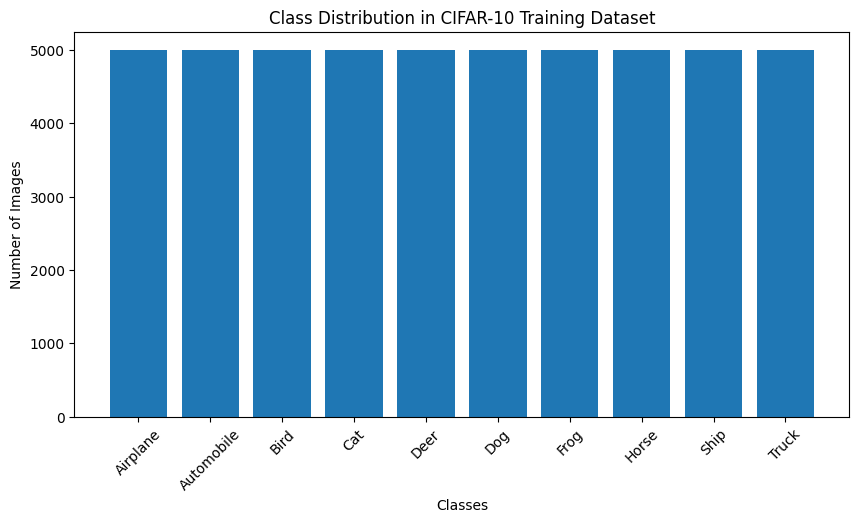

In [12]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,5))

plt.bar(class_names, counts)

plt.title("Class Distribution in CIFAR-10 Training Dataset")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
save_plot("class_distribution")
plt.show()

In [13]:
print("Number of Training Images :", len(X_train))
print("Number of Testing Images  :", len(X_test))

print("\nImage Shape :", X_train[0].shape)

print("Data Type :", X_train.dtype)

print("Pixel Value Range :",
      X_train.min(),
      "to",
      X_train.max())

print("\nNumber of Classes :", len(class_names))

Number of Training Images : 50000
Number of Testing Images  : 10000

Image Shape : (32, 32, 3)
Data Type : uint8
Pixel Value Range : 0 to 255

Number of Classes : 10


In [14]:
#Task-2
# Normalize Pixel Values

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training Data Type :", X_train.dtype)
print("Testing Data Type  :", X_test.dtype)

print("\nPixel Value Range")
print("Minimum :", X_train.min())
print("Maximum :", X_train.max())

Training Data Type : float32
Testing Data Type  : float32

Pixel Value Range
Minimum : 0.0
Maximum : 1.0


In [15]:
from tensorflow.keras.utils import to_categorical

# One-Hot Encode Labels

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Training Labels Shape :", y_train_cat.shape)
print("Testing Labels Shape  :", y_test_cat.shape)

Training Labels Shape : (50000, 10)
Testing Labels Shape  : (10000, 10)


In [16]:
print("Original Label :", y_train[0][0])

print("\nOne-Hot Encoded Label :")
print(y_train_cat[0])

Original Label : 6

One-Hot Encoded Label :
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [17]:
print("Training Images :", X_train.shape)
print("Training Labels :", y_train_cat.shape)

print("\nTesting Images :", X_test.shape)
print("Testing Labels :", y_test_cat.shape)

Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 10)

Testing Images : (10000, 32, 32, 3)
Testing Labels : (10000, 10)


Saved: first_image.eps


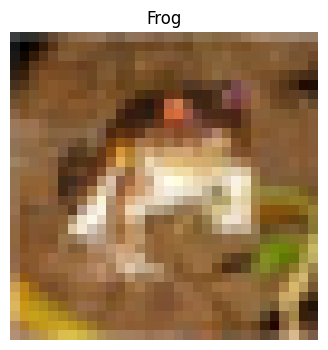

In [18]:
plt.figure(figsize=(4,4))

plt.imshow(X_train[0])

plt.title(class_names[np.argmax(y_train_cat[0])])

plt.axis("off")
save_plot("first_image")
plt.show()

In [19]:
#Task-3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [20]:
# Build CNN Model

model = Sequential()

# First Convolution Layer
model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    )
)

# First Pooling Layer
model.add(
    MaxPooling2D(
        pool_size=(2,2)
    )
)

# Second Convolution Layer
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    )
)

# Second Pooling Layer
model.add(
    MaxPooling2D(
        pool_size=(2,2)
    )
)

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(
    Dense(
        128,
        activation='relu'
    )
)

# Output Layer
model.add(
    Dense(
        10,
        activation='softmax'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
print("Total Parameters :", model.count_params())

Total Parameters : 545098


In [24]:
# Train the CNN Model

history = model.fit(
    X_train,
    y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 68ms/step - accuracy: 0.4706 - loss: 1.4736 - val_accuracy: 0.5476 - val_loss: 1.3174
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step - accuracy: 0.6037 - loss: 1.1254 - val_accuracy: 0.6309 - val_loss: 1.0642
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.6590 - loss: 0.9723 - val_accuracy: 0.6395 - val_loss: 1.0354
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.6995 - loss: 0.8641 - val_accuracy: 0.6743 - val_loss: 0.9459
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step - accuracy: 0.7298 - loss: 0.7748 - val_accuracy: 0.6900 - val_loss: 0.8980
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.7540 - loss: 0.7040 - val_accuracy: 0.6996 - val_loss: 0.9021
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - accuracy: 0.7789 - loss: 0.6333 - val_accuracy: 0.6837 - val_loss: 0.9662
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.8030 - loss: 0.5649 - 

In [25]:
print("Final Training Accuracy :",
      history.history['accuracy'][-1])

print("Final Validation Accuracy :",
      history.history['val_accuracy'][-1])

print("Final Training Loss :",
      history.history['loss'][-1])

print("Final Validation Loss :",
      history.history['val_loss'][-1])

Final Training Accuracy : 0.9682750105857849
Final Validation Accuracy : 0.6899999976158142
Final Training Loss : 0.0928645208477974
Final Validation Loss : 1.766244888305664


Saved: training_validation_accuracy.eps


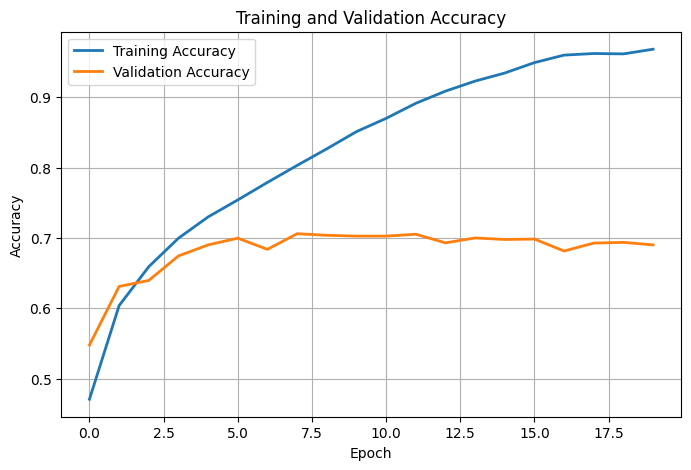

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy',
         linewidth=2)

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy',
         linewidth=2)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
save_plot("training_validation_accuracy")
plt.show()

Saved: training_validation_loss.eps


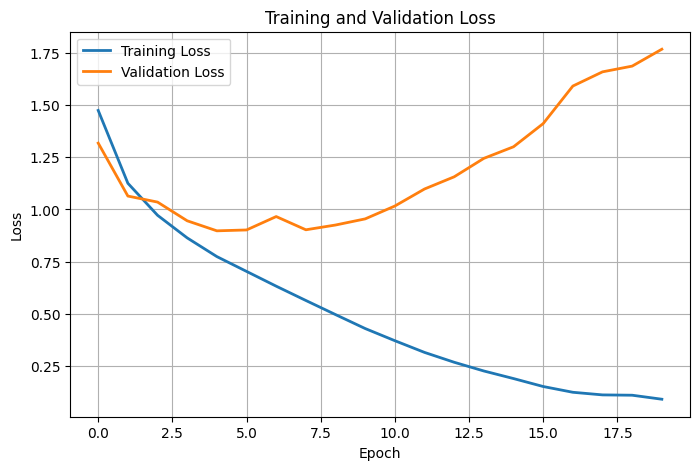

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss',
         linewidth=2)

plt.plot(history.history['val_loss'],
         label='Validation Loss',
         linewidth=2)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
save_plot("training_validation_loss")
plt.show()

In [28]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns

In [29]:
# Evaluate CNN on Test Data

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 0.6858
Test Loss     : 1.7919


In [30]:
# Predict Test Images

y_pred_prob = model.predict(X_test, verbose=0)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = y_test.flatten()

In [31]:
precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Precision : 0.6874
Recall    : 0.6858
F1-Score  : 0.6858


In [32]:
print("Classification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

Classification Report

              precision    recall  f1-score   support

    Airplane       0.70      0.74      0.72      1000
  Automobile       0.78      0.80      0.79      1000
        Bird       0.54      0.62      0.58      1000
         Cat       0.50      0.50      0.50      1000
        Deer       0.66      0.62      0.64      1000
         Dog       0.63      0.55      0.59      1000
        Frog       0.74      0.75      0.75      1000
       Horse       0.76      0.72      0.74      1000
        Ship       0.81      0.79      0.80      1000
       Truck       0.76      0.76      0.76      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000



Saved: confusion_matrix.eps


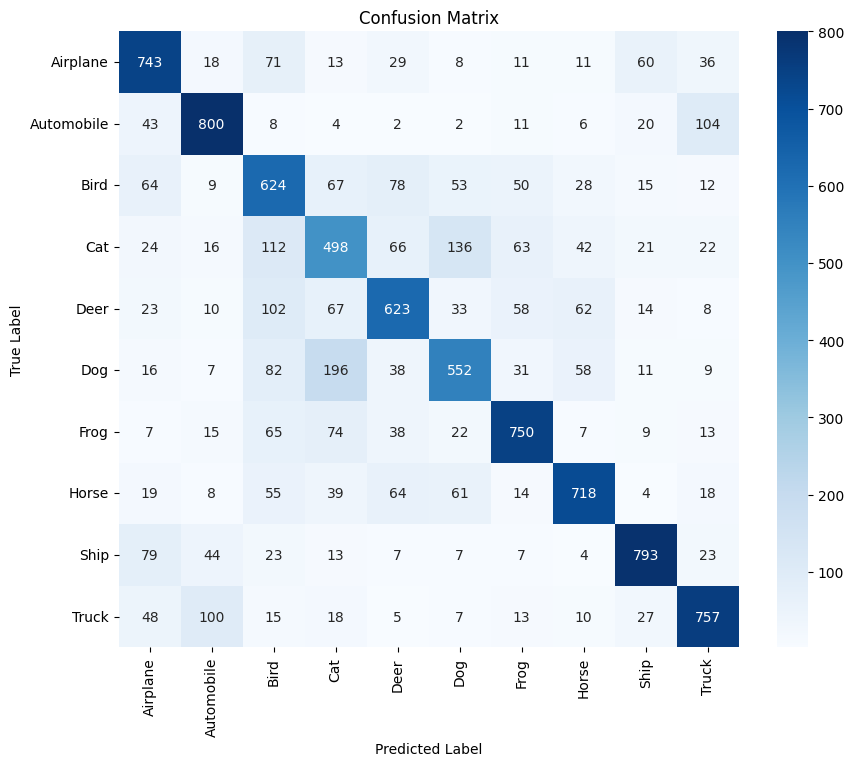

In [33]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
save_plot("confusion_matrix")
plt.show()

Saved: predictions.eps


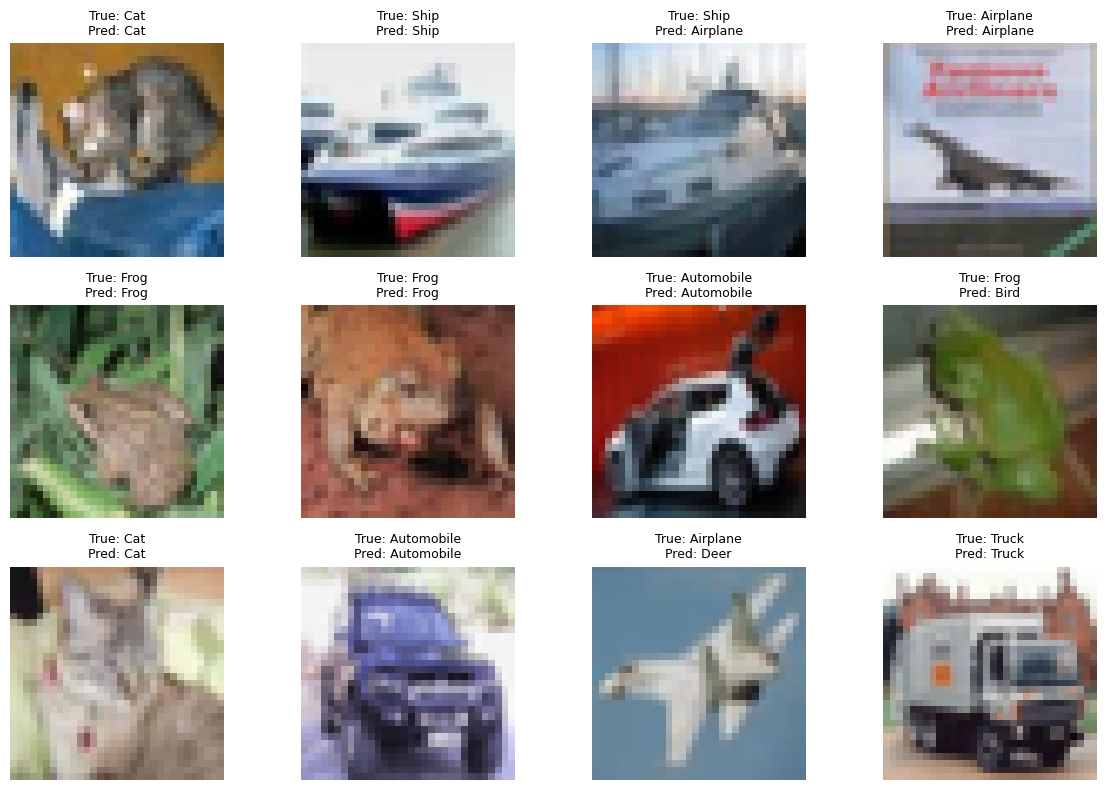

In [34]:
plt.figure(figsize=(12,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(X_test[i])

    plt.title(
        f"True: {class_names[y_true[i]]}\nPred: {class_names[y_pred[i]]}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
save_plot("predictions")
plt.show()

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

def build_model(filters=32,
                kernel_size=(3,3),
                optimizer='adam'):

    model = Sequential()

    model.add(
        Conv2D(filters=filters,
               kernel_size=kernel_size,
               activation='relu',
               padding='same',
               input_shape=(32,32,3))
    )

    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(
        Conv2D(filters=filters*2,
               kernel_size=kernel_size,
               activation='relu',
               padding='same')
    )

    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(Flatten())

    model.add(Dense(128, activation='relu'))

    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [36]:
filter_list = [16, 32, 64]

filter_results = []

for f in filter_list:

    print(f"\nTraining with {f} filters")

    model = build_model(filters=f)

    history = model.fit(
        X_train,
        y_train_cat,
        epochs=5,
        batch_size=64,
        validation_split=0.2,
        verbose=0
    )

    _, acc = model.evaluate(
        X_test,
        y_test_cat,
        verbose=0
    )

    filter_results.append(acc)

    print("Accuracy:", acc)


Training with 16 filters


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.6585000157356262

Training with 32 filters
Accuracy: 0.6980000138282776

Training with 64 filters
Accuracy: 0.6922000050544739


Saved: filter_comparison.eps


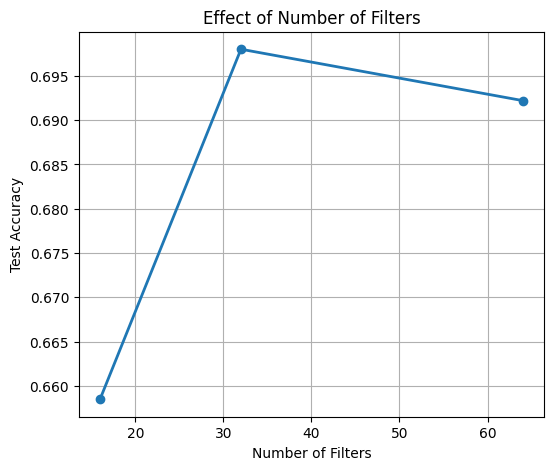

In [37]:
plt.figure(figsize=(6,5))

plt.plot(filter_list,
         filter_results,
         marker='o',
         linewidth=2)

plt.title("Effect of Number of Filters")

plt.xlabel("Number of Filters")

plt.ylabel("Test Accuracy")

plt.grid(True)
save_plot("filter_comparison")
plt.show()

In [38]:
kernel_list = [(3,3), (5,5)]

kernel_results = []

for k in kernel_list:

    print(f"\nTraining with Kernel Size {k}")

    model = build_model(kernel_size=k)

    history = model.fit(
        X_train,
        y_train_cat,
        epochs=5,
        batch_size=64,
        validation_split=0.2,
        verbose=0
    )

    _, acc = model.evaluate(
        X_test,
        y_test_cat,
        verbose=0
    )

    kernel_results.append(acc)

    print("Accuracy:", acc)


Training with Kernel Size (3, 3)
Accuracy: 0.7031000256538391

Training with Kernel Size (5, 5)
Accuracy: 0.6811000108718872


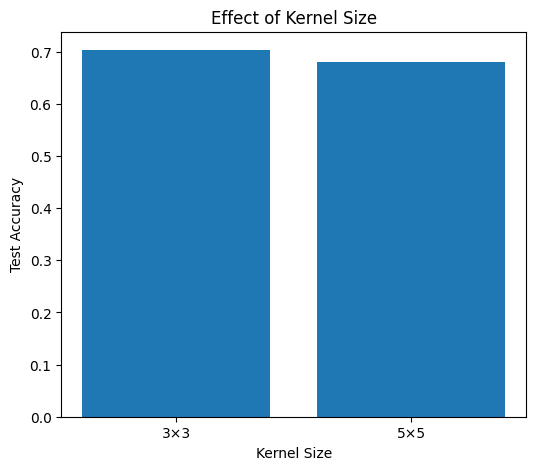

In [39]:
labels = ["3×3", "5×5"]

plt.figure(figsize=(6,5))

plt.bar(labels,
        kernel_results)

plt.title("Effect of Kernel Size")

plt.xlabel("Kernel Size")

plt.ylabel("Test Accuracy")

plt.show()

In [40]:
optimizer_list = ["adam", "sgd"]

optimizer_results = []

for opt in optimizer_list:

    print(f"\nTraining with {opt.upper()} Optimizer")

    model = build_model(optimizer=opt)

    history = model.fit(
        X_train,
        y_train_cat,
        epochs=5,
        batch_size=64,
        validation_split=0.2,
        verbose=0
    )

    _, acc = model.evaluate(
        X_test,
        y_test_cat,
        verbose=0
    )

    optimizer_results.append(acc)

    print("Accuracy:", acc)


Training with ADAM Optimizer
Accuracy: 0.6916999816894531

Training with SGD Optimizer
Accuracy: 0.5166000127792358


Saved: optimizer_comparison.eps


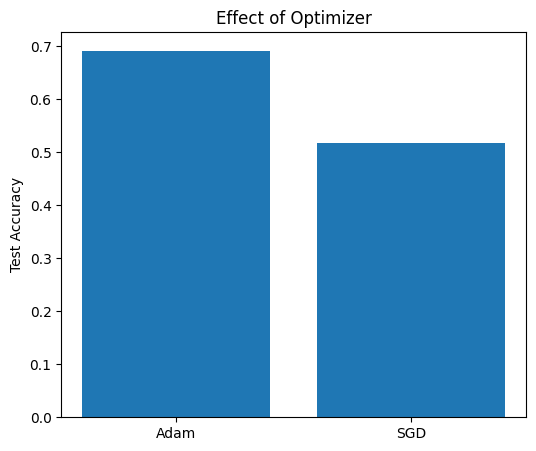

In [41]:
plt.figure(figsize=(6,5))

plt.bar(
    ["Adam", "SGD"],
    optimizer_results
)

plt.title("Effect of Optimizer")

plt.ylabel("Test Accuracy")
save_plot("optimizer_comparison")
plt.show()

In [42]:
import pandas as pd

summary = pd.DataFrame({

    "Hyperparameter": [
        "Filters (16)",
        "Filters (32)",
        "Filters (64)",
        "Kernel (3×3)",
        "Kernel (5×5)",
        "Optimizer (Adam)",
        "Optimizer (SGD)"
    ],

    "Accuracy": filter_results +
                kernel_results +
                optimizer_results
})

summary

,Hyperparameter,Accuracy
0,Filters (16),0.6585
1,Filters (32),0.6980
2,Filters (64),0.6922
3,Kernel (3×3),0.7031
4,Kernel (5×5),0.6811
5,Optimizer (Adam),0.6917
6,Optimizer (SGD),0.5166


In [43]:
from tensorflow.keras.layers import AveragePooling2D

def build_pooling_model(pooling='max'):

    model = Sequential()

    model.add(
        Conv2D(
            32,
            (3,3),
            activation='relu',
            padding='same',
            input_shape=(32,32,3)
        )
    )

    if pooling == 'max':
        model.add(MaxPooling2D(pool_size=(2,2)))
    else:
        model.add(AveragePooling2D(pool_size=(2,2)))

    model.add(
        Conv2D(
            64,
            (3,3),
            activation='relu',
            padding='same'
        )
    )

    if pooling == 'max':
        model.add(MaxPooling2D(pool_size=(2,2)))
    else:
        model.add(AveragePooling2D(pool_size=(2,2)))

    model.add(Flatten())

    model.add(Dense(128, activation='relu'))

    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [44]:
print("Training CNN with Max Pooling...\n")

max_model = build_pooling_model(pooling='max')

history_max = max_model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

max_loss, max_accuracy = max_model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print(f"\nMax Pooling Accuracy : {max_accuracy:.4f}")

Training CNN with Max Pooling...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 75ms/step - accuracy: 0.4687 - loss: 1.4792 - val_accuracy: 0.5887 - val_loss: 1.1855
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step - accuracy: 0.6191 - loss: 1.0919 - val_accuracy: 0.6309 - val_loss: 1.0473
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 70ms/step - accuracy: 0.6691 - loss: 0.9481 - val_accuracy: 0.6542 - val_loss: 0.9897
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 71ms/step - accuracy: 0.7035 - loss: 0.8553 - val_accuracy: 0.6708 - val_loss: 0.9363
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.7293 - loss: 0.7755 - val_accuracy: 0.7018 - val_loss: 0.8811

Max Pooling Accuracy : 0.6973


In [45]:
print("Training CNN with Average Pooling...\n")

avg_model = build_pooling_model(pooling='average')

history_avg = avg_model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

avg_loss, avg_accuracy = avg_model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print(f"\nAverage Pooling Accuracy : {avg_accuracy:.4f}")

Training CNN with Average Pooling...

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - accuracy: 0.4486 - loss: 1.5411 - val_accuracy: 0.5361 - val_loss: 1.3072
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 64ms/step - accuracy: 0.5730 - loss: 1.2145 - val_accuracy: 0.5994 - val_loss: 1.1498
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.6191 - loss: 1.0736 - val_accuracy: 0.6111 - val_loss: 1.1151
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.6587 - loss: 0.9688 - val_accuracy: 0.6407 - val_loss: 1.0189
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.6879 - loss: 0.8916 - val_accuracy: 0.6584 - val_loss: 0.9783

Average Pooling Accuracy : 0.6592


Saved: pooling_comparison.eps


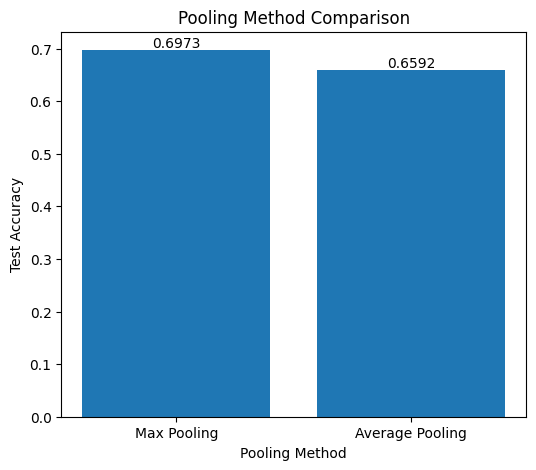

In [46]:
plt.figure(figsize=(6,5))

pooling_methods = ["Max Pooling", "Average Pooling"]
accuracies = [max_accuracy, avg_accuracy]

plt.bar(pooling_methods, accuracies)

plt.title("Pooling Method Comparison")
plt.xlabel("Pooling Method")
plt.ylabel("Test Accuracy")

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.005, f"{value:.4f}", ha='center')
save_plot("pooling_comparison")
plt.show()

Saved: training_accuracy_comparison.eps


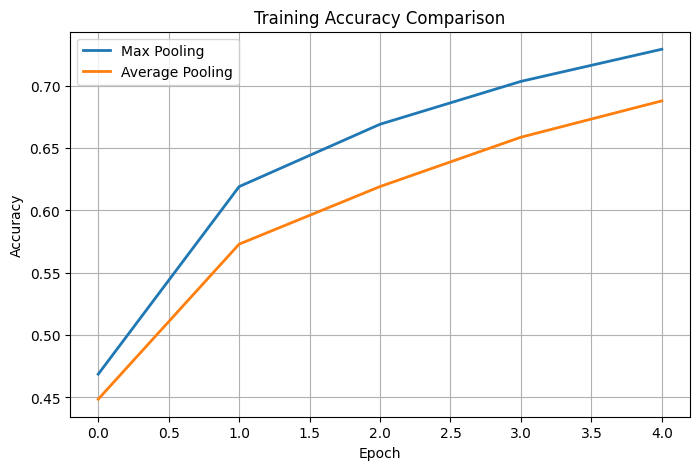

In [47]:
plt.figure(figsize=(8,5))

plt.plot(
    history_max.history['accuracy'],
    label='Max Pooling',
    linewidth=2
)

plt.plot(
    history_avg.history['accuracy'],
    label='Average Pooling',
    linewidth=2
)

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
save_plot("training_accuracy_comparison")
plt.show()

Saved: validation_accuracy_comparison.eps


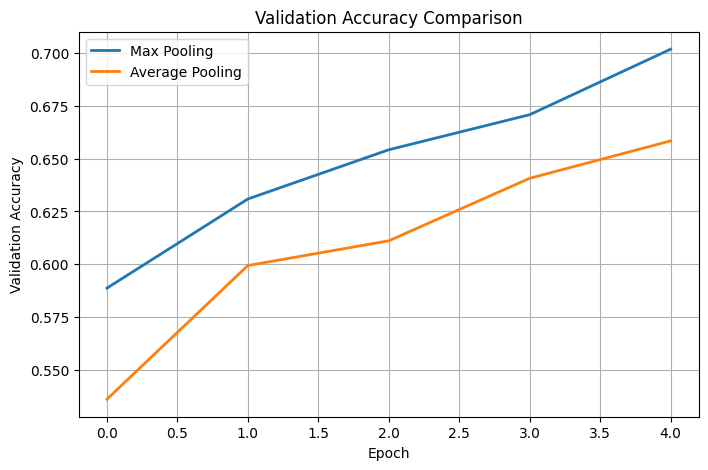

In [48]:
plt.figure(figsize=(8,5))

plt.plot(
    history_max.history['val_accuracy'],
    label='Max Pooling',
    linewidth=2
)

plt.plot(
    history_avg.history['val_accuracy'],
    label='Average Pooling',
    linewidth=2
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
save_plot("validation_accuracy_comparison")
plt.show()

In [49]:
comparison = pd.DataFrame({
    "Pooling Method": [
        "Max Pooling",
        "Average Pooling"
    ],
    "Test Accuracy": [
        max_accuracy,
        avg_accuracy
    ]
})

comparison

,Pooling Method,Test Accuracy
0,Max Pooling,0.6973
1,Average Pooling,0.6592


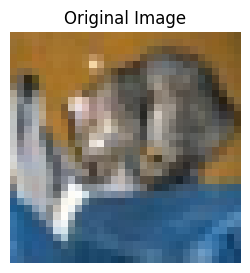

Actual Class : Cat


In [50]:
from tensorflow.keras.models import Model

# Select a Test Image

image = X_test[0]

plt.figure(figsize=(3,3))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

print("Actual Class :", class_names[y_test[0][0]])

In [51]:
# Extract Outputs of Convolution Layers

feature_model = Model(
    inputs=model.inputs,
    outputs=[
        model.layers[0].output,   # First Conv2D
        model.layers[2].output    # Second Conv2D
    ]
)

In [52]:
for i, layer in enumerate(model.layers):
    print(i, layer.name)

0 conv2d_14
1 max_pooling2d_14
2 conv2d_15
3 max_pooling2d_15
4 flatten_7
5 dense_14
6 dense_15


In [53]:
# Generate Feature Maps

image_batch = np.expand_dims(image, axis=0)

feature_maps = feature_model.predict(image_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


Saved: feature_maps_conv1.eps


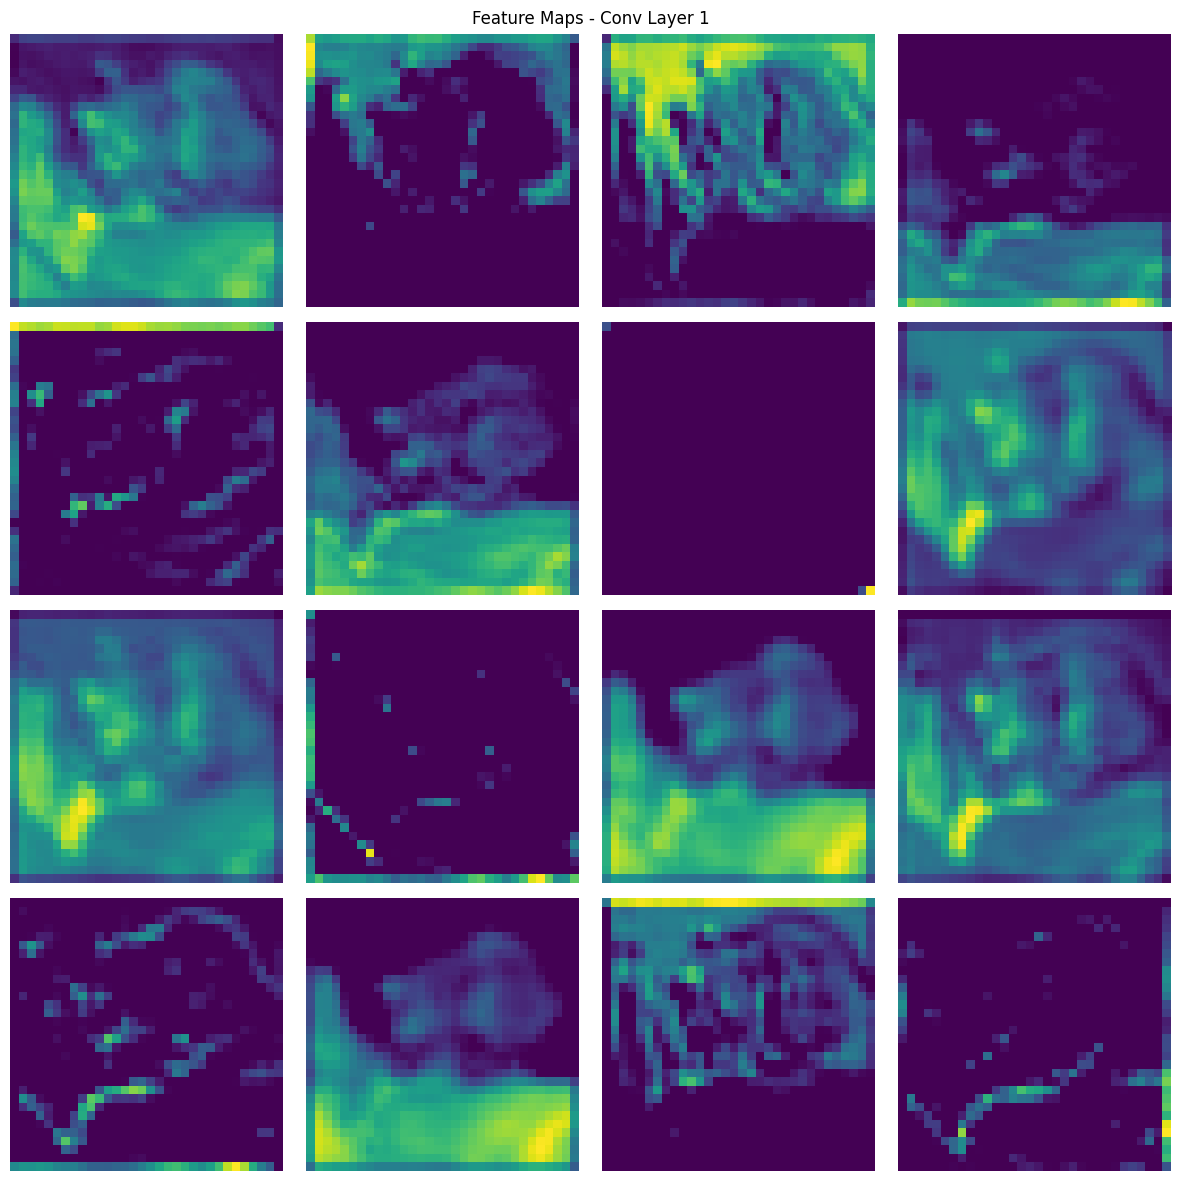

In [54]:
plt.figure(figsize=(12,12))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        feature_maps[0][0, :, :, i],
        cmap="viridis"
    )

    plt.axis("off")

plt.suptitle("Feature Maps - Conv Layer 1")

plt.tight_layout()
save_plot("feature_maps_conv1")
plt.show()

Saved: feature_maps_conv2.eps


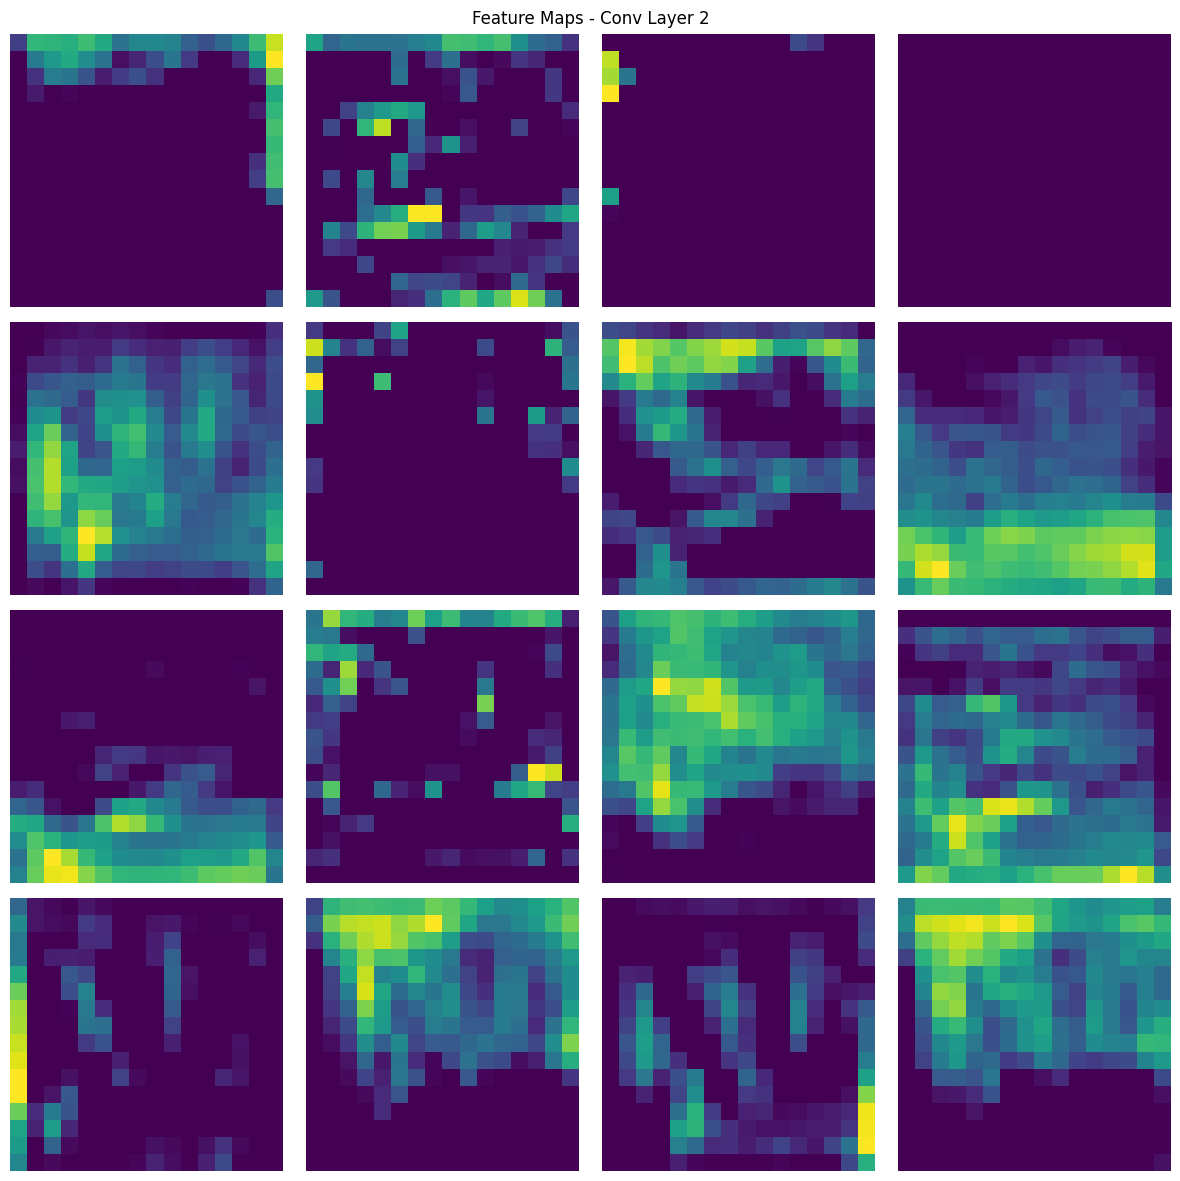

In [55]:
plt.figure(figsize=(12,12))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        feature_maps[1][0, :, :, i],
        cmap="viridis"
    )

    plt.axis("off")

plt.suptitle("Feature Maps - Conv Layer 2")

plt.tight_layout()
save_plot("feature_maps_conv2")
plt.show()

Saved: original_and_feature_maps.eps


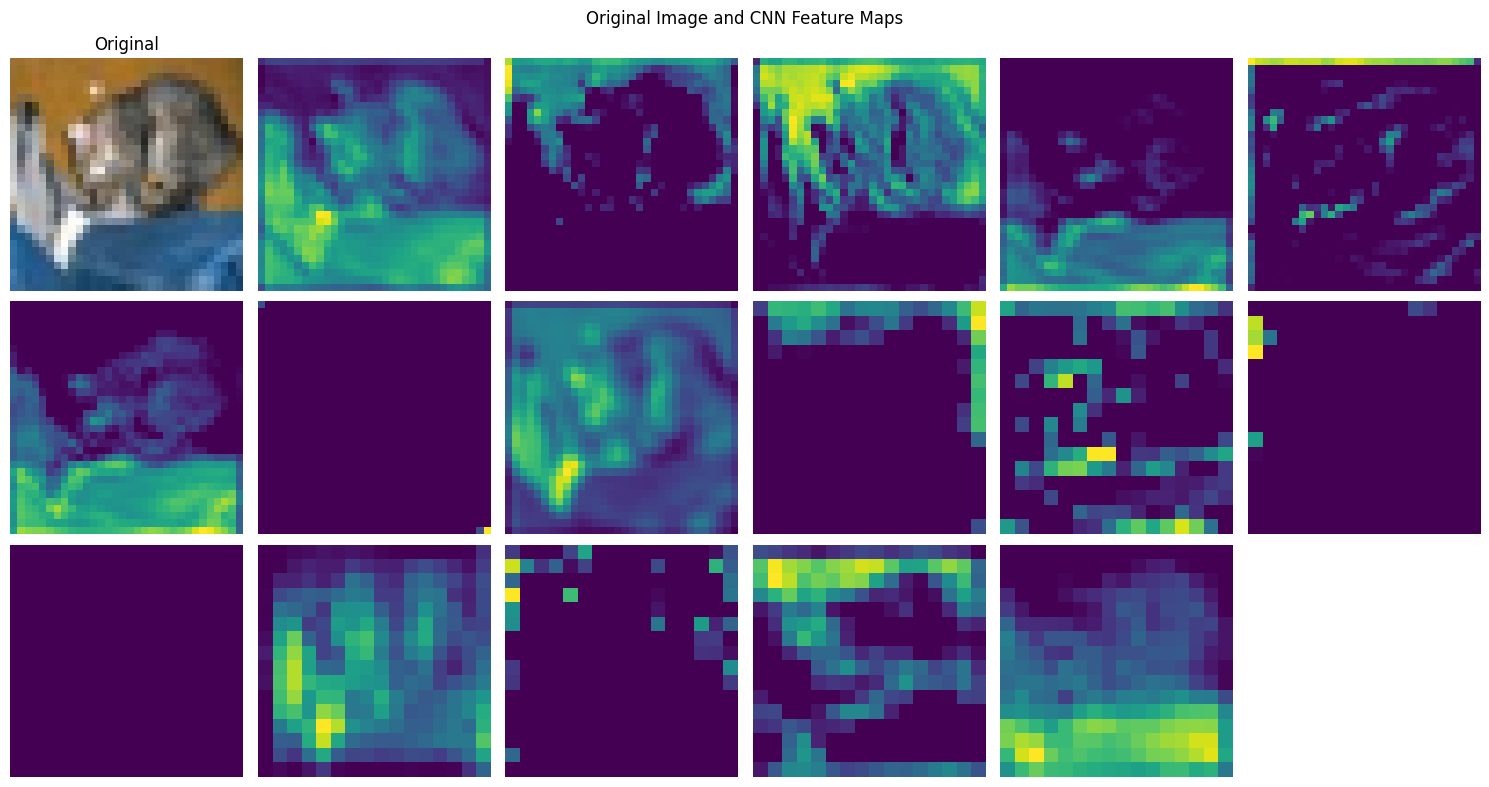

In [56]:
plt.figure(figsize=(15,8))

# Original Image
plt.subplot(3,6,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

# First 8 Feature Maps from Conv Layer 1
for i in range(8):
    plt.subplot(3,6,i+2)
    plt.imshow(feature_maps[0][0, :, :, i], cmap="viridis")
    plt.axis("off")

# First 8 Feature Maps from Conv Layer 2
for i in range(8):
    plt.subplot(3,6,i+10)
    plt.imshow(feature_maps[1][0, :, :, i], cmap="viridis")
    plt.axis("off")

plt.suptitle("Original Image and CNN Feature Maps")

plt.tight_layout()
save_plot("original_and_feature_maps")
plt.show()

In [57]:
#Task-9
# Display Model Summary

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,100 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [58]:
# Total Parameters

print("Total Parameters      :", model.count_params())

print("Trainable Parameters :", sum(
    np.prod(v.shape) for v in model.trainable_weights
))

print("Non-Trainable Parameters :", sum(
    np.prod(v.shape) for v in model.non_trainable_weights
))

Total Parameters      : 545098
Trainable Parameters : 545098
Non-Trainable Parameters : 0


In [59]:
# Layer-wise Parameter Analysis

print("{:<20} {:<20} {:<15}".format(
    "Layer",
    "Output Shape",
    "Parameters"
))

print("-"*60)

for layer in model.layers:

    print("{:<20} {:<20} {:<15}".format(
        layer.name,
        str(layer.output.shape),
        layer.count_params()
    ))

Layer                Output Shape         Parameters     
------------------------------------------------------------
conv2d_14            (None, 32, 32, 32)   896            
max_pooling2d_14     (None, 16, 16, 32)   0              
conv2d_15            (None, 16, 16, 64)   18496          
max_pooling2d_15     (None, 8, 8, 64)     0              
flatten_7            (None, 4096)         0              
dense_14             (None, 128)          524416         
dense_15             (None, 10)           1290           


Saved: parameter_distribution.eps


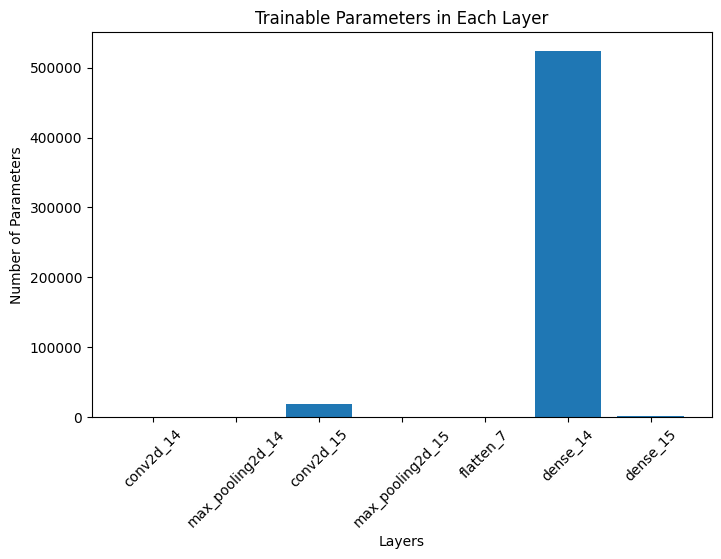

In [60]:
# Parameters per Layer

layer_names = []
layer_params = []

for layer in model.layers:

    layer_names.append(layer.name)
    layer_params.append(layer.count_params())

plt.figure(figsize=(8,5))

plt.bar(layer_names, layer_params)

plt.title("Trainable Parameters in Each Layer")

plt.xlabel("Layers")

plt.ylabel("Number of Parameters")

plt.xticks(rotation=45)
save_plot("parameter_distribution")
plt.show()

In [61]:
# Percentage Contribution of Each Layer

total_params = model.count_params()

for layer in model.layers:

    percentage = (layer.count_params()/total_params)*100

    print(f"{layer.name:20s} : {percentage:.2f}%")

conv2d_14            : 0.16%
max_pooling2d_14     : 0.00%
conv2d_15            : 3.39%
max_pooling2d_15     : 0.00%
flatten_7            : 0.00%
dense_14             : 96.21%
dense_15             : 0.24%


Saved: parameter_distribution_pie.eps


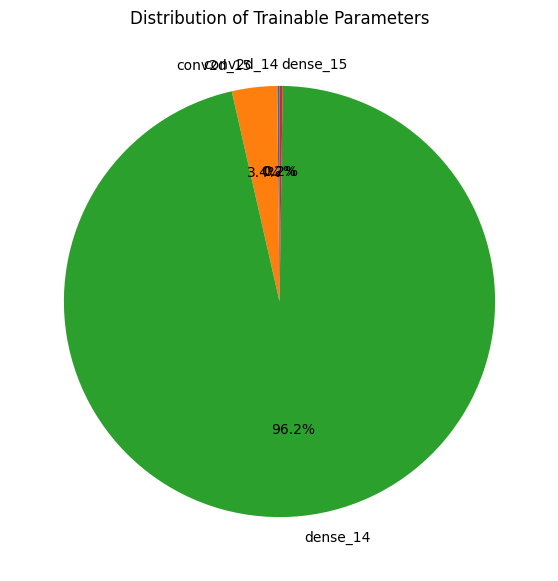

In [62]:
# Pie Chart of Parameter Distribution

labels = []
sizes = []

for layer in model.layers:
    if layer.count_params() > 0:
        labels.append(layer.name)
        sizes.append(layer.count_params())

plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Trainable Parameters")
save_plot("parameter_distribution_pie")
plt.show()

In [63]:
#Task-10
# Performance Summary

performance = {
    "Metric": [
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Value": [
        test_accuracy,
        precision,
        recall,
        f1
    ]
}

performance_df = pd.DataFrame(performance)

performance_df

,Metric,Value
0,Test Accuracy,0.685800
1,Precision,0.687387
2,Recall,0.685800
3,F1-Score,0.685846


Saved: cnn_performance_metrics.eps


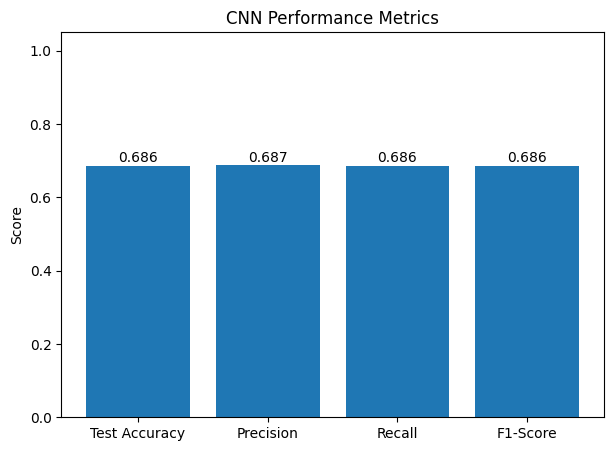

In [64]:
plt.figure(figsize=(7,5))

plt.bar(
    performance_df["Metric"],
    performance_df["Value"]
)

plt.title("CNN Performance Metrics")
plt.ylabel("Score")
plt.ylim(0,1.05)

for i, value in enumerate(performance_df["Value"]):
    plt.text(i, value+0.01, f"{value:.3f}", ha='center')
save_plot("cnn_performance_metrics")
plt.show()

Saved: accuracy_loss_curve.eps


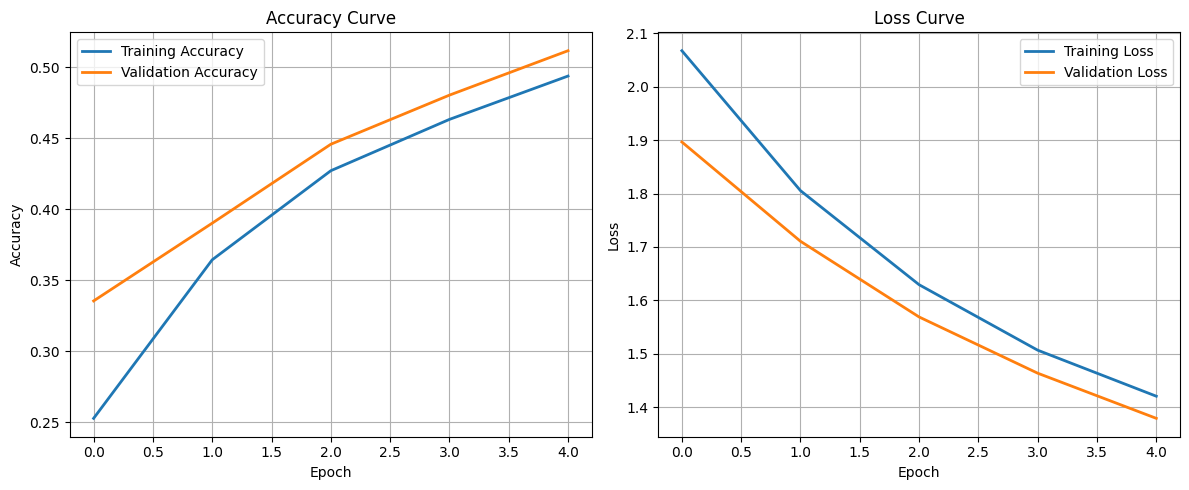

In [65]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
save_plot("accuracy_loss_curve")
plt.show()

In [66]:
history_df = pd.DataFrame({

    "Epoch": range(1, len(history.history["accuracy"])+1),

    "Training Accuracy": history.history["accuracy"],

    "Validation Accuracy": history.history["val_accuracy"],

    "Training Loss": history.history["loss"],

    "Validation Loss": history.history["val_loss"]

})

history_df

,Epoch,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,1,0.252775,0.3355,2.067517,1.896550
1,2,0.364500,0.3903,1.805413,1.710566
2,3,0.427250,0.4459,1.629253,1.568820
3,4,0.463400,0.4805,1.506580,1.463482
4,5,0.493950,0.5118,1.420373,1.378909


In [67]:
print("="*50)
print("CNN MODEL PERFORMANCE SUMMARY")
print("="*50)

print(f"Training Accuracy   : {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy : {history.history['val_accuracy'][-1]:.4f}")

print(f"\nTest Accuracy       : {test_accuracy:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1-Score            : {f1:.4f}")

print("\nTotal Parameters :", model.count_params())

print("="*50)

CNN MODEL PERFORMANCE SUMMARY
Training Accuracy   : 0.4940
Validation Accuracy : 0.5118

Test Accuracy       : 0.6858
Precision           : 0.6874
Recall              : 0.6858
F1-Score            : 0.6858

Total Parameters : 545098


Saved: predictions_2.eps


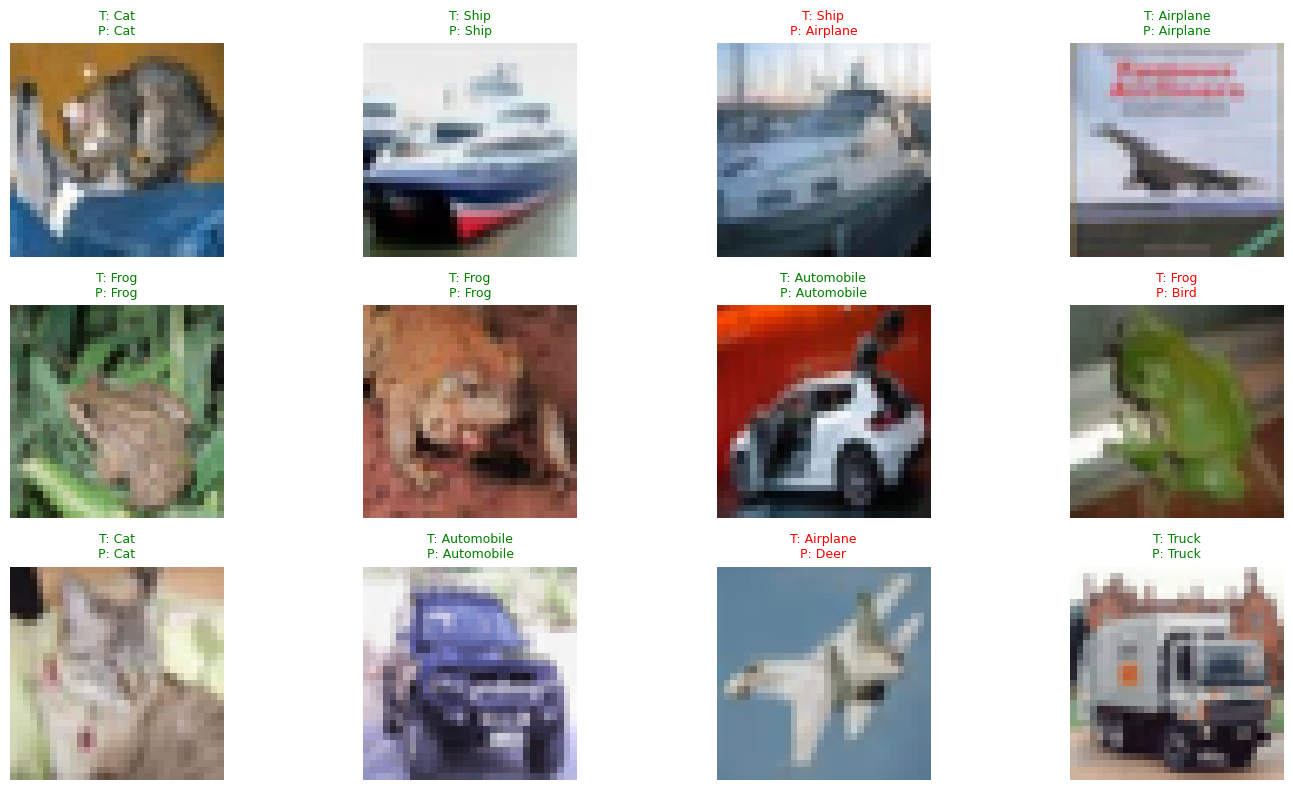

In [68]:
plt.figure(figsize=(15,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(X_test[i])

    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred[i]]

    color = "green" if true_label == pred_label else "red"

    plt.title(
        f"T: {true_label}\nP: {pred_label}",
        color=color,
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
save_plot("predictions_2")
plt.show()

In [69]:
import shutil

zip_name = "all_plots_eps"

shutil.make_archive(zip_name, 'zip', save_dir)

print("ZIP file created!")

ZIP file created!


In [70]:
from google.colab import files

files.download("all_plots_eps.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>